In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

import h5py
import sys
sys.path.append('../')
import analysis_utils as utils

from scipy.signal import decimate

utils.load_plotting_setting()

In [2]:
c_mv = 8.263269630174246e-08
amp2kev = 7157.624533259538
sigma_p = 176.79818534573002

sigma_amp = sigma_p / amp2kev

In [ ]:
# sphere = 'sphere_20250103'
# datasets = [
#             '20250104_4e-8mbar_alignment0_long',
#             '20250105_2e-8mbar_alignment0_long',
#             '20250106_2e-8mbar_8e_alignment0_long',
#             '20250107_1e-8mbar_8e_alignment0_long',
#             '20250108_1e-8mbar_8e_alignment0_long',
#             '20250109_1e-8mbar_8e_alignment1_long',
#             '20250110_1e-8mbar_8e_alignment1_long',
#             '20250111_1e-8mbar_8e_alignment1_long',
#             '20250112_9e-9mbar_8e_alignment1_long',
#             '20250113_5e-8mbar_8e_alignment1_long',
#             '20250114_1e-8mbar_1e_alignment1_long',
#             '20250115_8e-9mbar_0e_alignment1_long',
#             '20250116_8e-9mbar_0e_alignment1_long_wrong_lo',
#             '20250117_8e-9mbar_0e_alignment1_long',
#             '20250118_8e-9mbar_1e_alignment1_long',
#             '20250120_8e-9mbar_1e_alignment1_long_wbackscat',
#             '20250121_8e-9mbar_1e_alignment1_long',
#             '20250122_8e-9mbar_1e_alignment1_long',
#             '20250123_7e-9mbar_1e_alignment1_long',
#             '20250124_7e-9mbar_1e_alignment1_long',
#             '20250125_7e-9mbar_1e_alignment1_long'    
#         ]
# data_prefixs = [
#                 '20250104_d_',
#                 '20250105_d_',
#                 '20250106_d_',
#                 '20250107_d_',
#                 '20250108_d_',
#                 '20250109_d_',
#                 '20250110_d_',
#                 '20250111_d_',
#                 '20250112_d_',
#                 '20250113_d_',
#                 '20250114_d_',
#                 '20250115_d_',
#                 '20250116_d_',
#                 '20250117_d_',
#                 '20250118_d_',
#                 '20250120_d_',
#                 '20250121_d_',
#                 '20250122_d_',
#                 '20250123_d_',
#                 '20250124_d_',
#                 '20250125_d_',
#                 ]
# n_files = [1440, 900, 1440, 1440, 1440, 1440, 1440, 1440, 780, 1440, 1440, 1440, 1440, 1440, 1983, 
#            1463, 1440, 1440, 1440, 1440, 1121]

#### Noise level count for one day of data
Can easily extend to the full dataset

In [21]:
noise_level_all = []
for i in range(1440):
    f = h5py.File(f'/Volumes/LaCie/dm_data_processed_amp_chisquare/sphere_20250103/20250104_4e-8mbar_alignment0_long/20250104_d_{i}_processed.hdf5', 'r')
    good_detection = f['data_processed']['good_detection'][:]
    noise_level = (f['data_processed']['noise_level_amp'][:])

    noise_level[np.logical_not(good_detection)] = np.nan
    noise_level_all.append(noise_level)
    f.close()

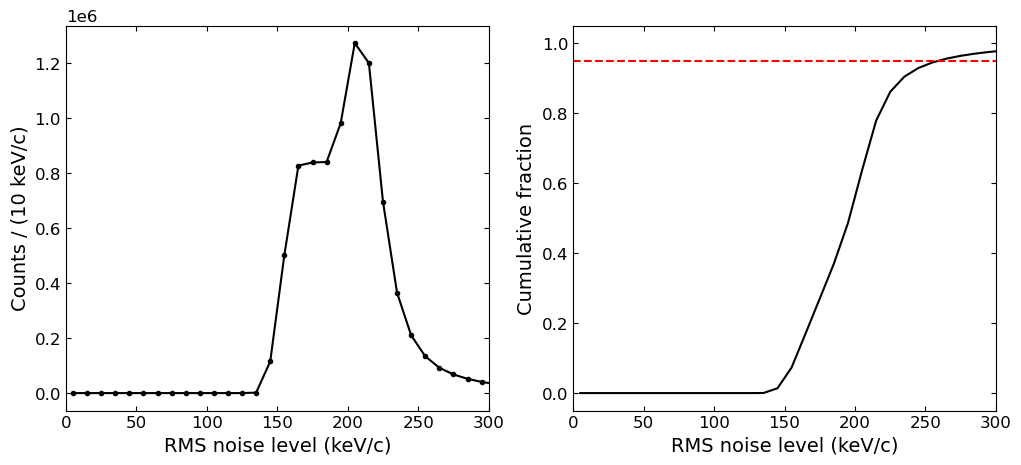

In [31]:
bins = np.arange(0, 1000, 10)
bc = 0.5 * (bins[1:] + bins[:-1])

hh, _ = np.histogram(np.ravel(noise_level_all) * amp2kev, bins)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(bc, hh, 'k.-')
axes[0].set_ylabel('Counts / (10 keV/c)')

axes[1].plot(bc, np.cumsum(hh)/np.cumsum(hh)[-1], 'k')
axes[1].hlines(0.95, 0, 1000, 'r', linestyle='--')
axes[1].set_ylabel('Cumulative fraction')

for ax in axes:
    ax.set_xlabel('RMS noise level (keV/c)')
    ax.set_xlim(0, 300)
# plt.yscale('log')
# plt.xlim(0, 200)

## $\chi^2$ test

In [33]:
noise_thr = 250

amp_all, chi2_all = [], []
for i in range(50):
    f = h5py.File(f'/Volumes/LaCie/dm_data_processed_amp_chisquare/sphere_20250103/20250104_4e-8mbar_alignment0_long/20250104_d_{i}_processed.hdf5', 'r')
    amplitude = f['data_processed']['amplitude'][:]
    idx_in_window = f['data_processed']['idx_in_window'][:]
    good_detection = f['data_processed']['good_detection'][:]
    noise_level_amp = f['data_processed']['noise_level_amp'][:]
    chisquare_short = f['data_processed']['chisquare_short'][:]

    good_noise = (noise_level_amp * amp2kev) < noise_thr
    good_det_noise = np.logical_and(good_detection, good_noise)

    amp_all.append(amplitude[good_det_noise])
    chi2_all.append(chisquare_short[good_det_noise])
    f.close()

Text(0, 0.5, '$\\chi^2$')

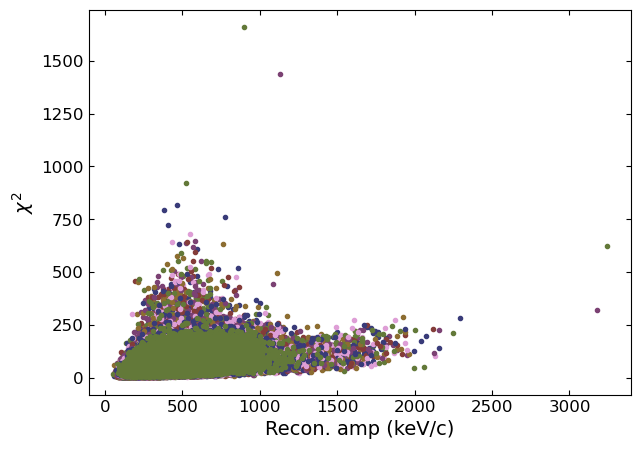

In [34]:
for i in range(50):
    plt.plot(np.abs(amp_all[i].flatten()) * amp2kev, chi2_all[i].flatten(), '.')

plt.xlabel('Recon. amp (keV/c)')
plt.ylabel(r'$\chi^2$')

In [35]:
idx_file, idx_window = 733, 1403

window_length = 5000
f = h5py.File(f'/Users/yuhan/work/nanospheres/data/dm_data/sphere_20250103/20250114_1e-8mbar_1e_alignment1_long/20250114_d_{idx_file}.hdf5', 'r')

dtt = f['data'].attrs['delta_t']
fs = int(np.ceil(1 / dtt))   # Sampling rate at Hz
zz = f['data']['channel_d'][:] * f['data']['channel_d'].attrs['adc2mv'] / 1e3  # Signal in V
f.close()

zz_bp = utils.bandpass_filtered(zz, fs, 30000, 80000)
zz_bp_shaped = np.reshape(zz_bp, (int(zz_bp.size / window_length), window_length))

_zz_bp = zz_bp_shaped[idx_window]
_amp, amp_lp, temp = utils.recon_force(dtt, _zz_bp, c_mv=None)

idx_pulse = np.argmax(np.abs(amp_lp[100:-50])) + 100

In [36]:
def get_normalized_template(sphere, voltage, bounds=(1000, 2000), downsampled=False):
    pulse_shape_file = np.load(rf'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/pulse_shape/{sphere}_pulse_shape_template_{voltage}v.npz')
    pulse_shapes = pulse_shape_file['pulse_shape']
    pulse_shape_template = np.mean(pulse_shapes, axis=0)

    normalized_template = pulse_shape_template / np.max(pulse_shape_template)

     # Take the central values around the peak
    ret = normalized_template[bounds[0]:bounds[1]]

    # Downsample to 500 kHz (so the 200 us template has 100 indices)
    if downsampled:
        ret_downsampled = decimate(ret, 10)
        return ret_downsampled / np.max(ret_downsampled)
    else:
        return ret

normalized_template_downsampled_short = get_normalized_template('sphere_20250103', voltage=20, bounds=(1250, 1750), downsampled=True)


In [37]:
template_scaled = normalized_template_downsampled_short * amp_lp[idx_pulse]

In [38]:
n_realization = 20000
noise = np.random.normal(0, sigma_amp, 50*n_realization)
noise = noise.reshape(n_realization, 50)

In [39]:
chi2 = np.empty(n_realization)
for i in range(n_realization):
    waveform = amp_lp[idx_pulse-25:idx_pulse+25] + noise[i]
    chi2[i] = np.sum( ((waveform - template_scaled)/sigma_amp)**2 )

In [43]:
626.94 / amp_lp[idx_pulse]

-922.1995256295266

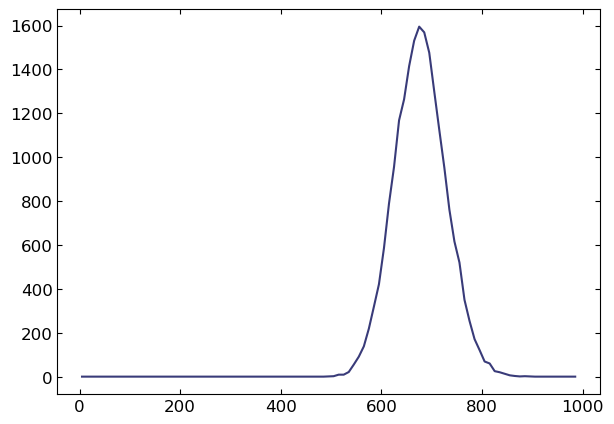

In [40]:
bins = np.arange(0, 1000, 10)
bc = 0.5 * (bins[1:] + bins[:-1])

hh, _ = np.histogram(chi2, bins)
plt.plot(bc, hh)

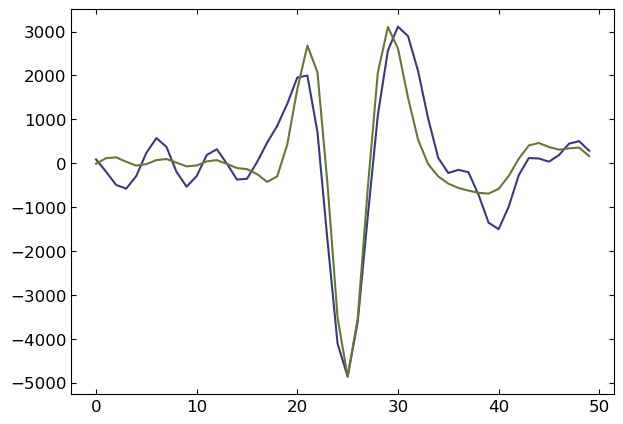

In [41]:
plt.plot(amp_lp[idx_pulse-25:idx_pulse+25] * amp2kev)
plt.plot(normalized_template_downsampled_short * amp_lp[idx_pulse] * amp2kev)